In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patches as rect
import seaborn as sns

In [2]:
BIG_6 = ["Arsenal", "Chelsea", "Liverpool", "Manchester City", "Manchester United", "Tottenham"]

## BIG6の時間帯別失点数の推移

In [3]:
df_interval_data = pd.read_csv("data/processed/cleaned_interval_data.csv").copy()

In [4]:
fifteen_min_stats = df_interval_data.groupby(["team", "interval"], as_index=False).agg(fifteen_min_GA_mean=("goals_against", "mean"))

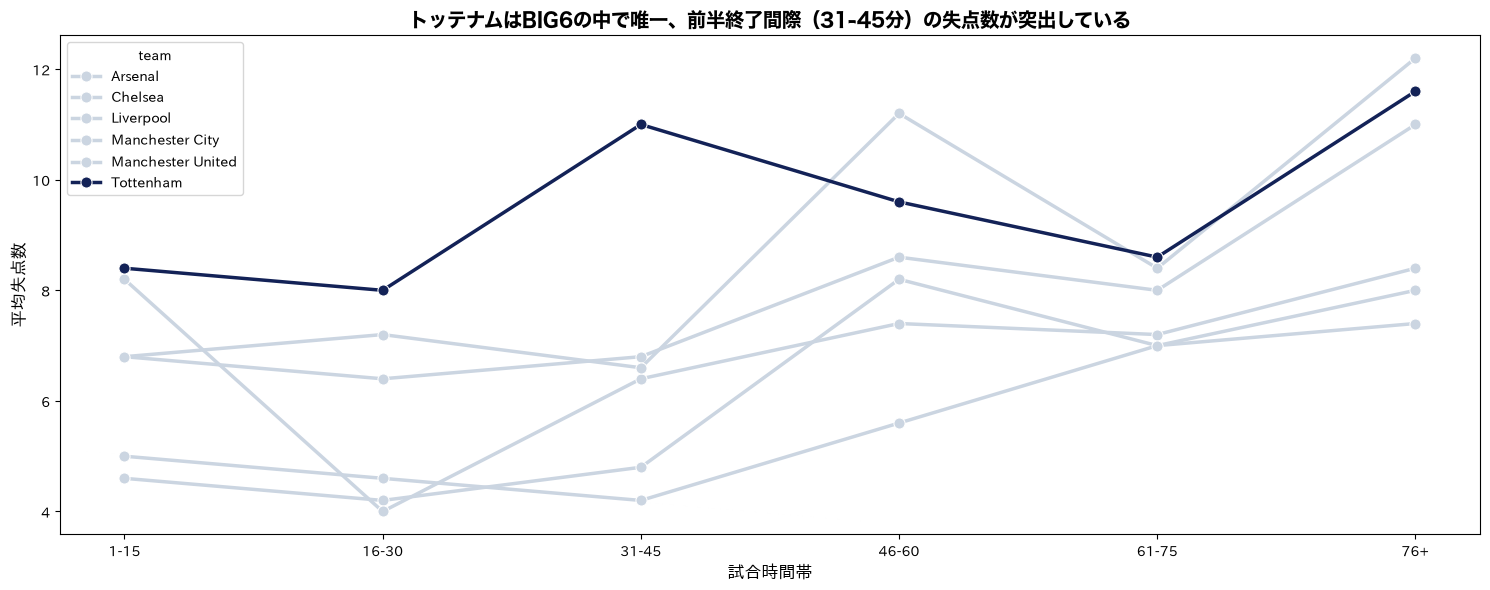

In [30]:
plt.figure(figsize=(15,6))

# トッテナムのデータを強調する
team_colour = {
    team: "#132257" if team == "Tottenham" else "#CBD5E1" for team in set(fifteen_min_stats["team"])
}

ax = sns.lineplot(
    data = fifteen_min_stats,
    x="interval",
    y = "fifteen_min_GA_mean",
    hue="team",
    palette = team_colour,
    marker="o",
    markersize=8,
    hue_order=BIG_6,
    linewidth=2.5
)

plt.title("トッテナムはBIG6の中で唯一、前半終了間際（31-45分）の失点数が突出している", fontsize=14, fontname="Hiragino Sans", fontweight="bold")
plt.xlabel("試合時間帯", fontsize=12)
plt.ylabel("平均失点数", fontsize=12)

plt.tight_layout()
plt.show()

## 【発見】トッテナムの脆弱性は「前半終了間際（31−45分）」に集中している
1.  前半終盤（31-45分）における「圧倒的な異質」
    - 平均失点数（11.0）は、BIG6の他のクラブと比較して突出し孤立した異常値
  
2.  後半終盤（76+）の失点数は「リーグ全体の傾向」の範囲内
    - 後半終盤の失点数（11.6）は前半よりわずかに高いものの、BIG6内の他2チームと同等水準であり、トッテナム固有の弱点とは言えない。


In [6]:
# 時間帯別データをトッテナムに絞る
tottenham_fifteen_min_stats = df_interval_data[df_interval_data["team"] == "Tottenham"]
# 前半終了間際（31-45分）に絞る
tottenham_late_1st = tottenham_fifteen_min_stats[tottenham_fifteen_min_stats["interval"] == "31-45"]

In [7]:
# 3つのカラムを抽出してクロス集計表に変換
heatmap_data = tottenham_fifteen_min_stats.pivot_table(index="interval", columns="season", values="goals_against")

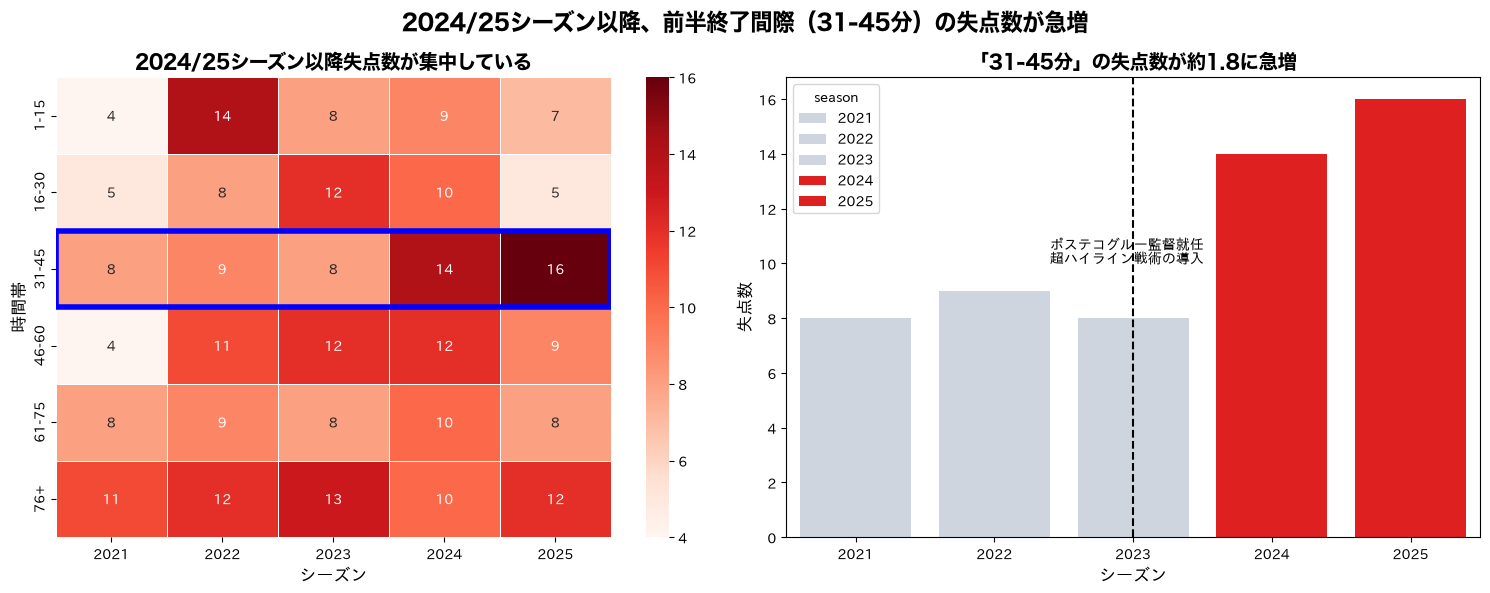

In [63]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("2024/25シーズン以降、前半終了間際（31-45分）の失点数が急増", fontsize=16, fontname="Hiragino Sans", fontweight="bold")

ax = sns.heatmap(
    ax = axs[0],
    data = heatmap_data,
    annot=True,
    fmt="g",
    cmap="Reds",
    linewidths=0.5
)
# 強調したい行「31-45分」のY軸の位置を取得
y_idx = heatmap_data.index.get_loc("31-45")
# 「31-45分」の行全体を囲む枠を追加
ax.add_patch(
    rect.Rectangle(
        (0, y_idx),
        len(heatmap_data.columns),
        1,
        fill=False,
        edgecolor="blue",
        lw=4,
        zorder=10
    )
)
axs[0].set_title("2024/25シーズン以降失点数が集中している", fontsize=14, fontname="Hiragino Sans", fontweight="bold")
axs[0].set_xlabel("シーズン", fontsize=12)
axs[0].set_ylabel("時間帯", fontsize=12)

colours = [
    "red" if val >= 2024 else "#CBD5E1" for val in tottenham_late_1st["season"]
]

sns.barplot(
    ax = axs[1],
    data = tottenham_late_1st,
    x = "season",
    y = "goals_against",
    hue = "season",
    palette = colours
)

axs[1].set_title("「31-45分」の失点数が約1.8に急増", fontsize=14, fontname="Hiragino Sans", fontweight="bold")
axs[1].set_xlabel("シーズン", fontsize=12)
axs[1].set_ylabel("失点数", fontsize=12)
axs[1].axvline(x=2, color="black", linestyle="--")
axs[1].text(x=1.4, y=10, s="ポステコグルー監督就任\n超ハイライン戦術の導入")

plt.tight_layout()
plt.show()

### 【検証】「31-45分」の時間帯は本当に失点が多いのか？

- 2024/25から2025/26シーズンの「31-45分」マークの失点数は他のシーズンと比べて圧倒的に増えている。
- 2021/22から2023/24シーズの平均と2024/25から2025/26の平均失点数を比較すると**約1.8倍多く失点**していることが判明。


過去５シーズンの「31-45分（前半終盤）」における失点数とxGA（被ゴール期待値）を時系列に追跡した結果、低迷に至るフェーズの変化が判明した。

1. **2021-2023シーズン（安定期）：**
    失点数（8〜9点）とxGA（9.0〜10.9）が拮抗しており、再現性の高いゲームマネジメントが機能していた。
3. **2024シーズン（構造崩壊フェーズ）：**
    xGAが15.34まで跳ね上がり、それに比例して失点（14点）も激増。戦術的な守備破綻（被決定機の急増）が主因であった。
3. **2025シーズン（自滅・メンタル崩壊フェーズ）：**
    xGAは10.30まで改善したにも関わらず、失点数は過去最高の**16点**を記録。**期待値に対して+5.7ゴール」という大幅な下振れ（乖離）** が発生した。



#### 【補足：定量要因（ドメイン知識）による定量的結果の解釈】
2025シーズンの「31-45分」における大幅な過剰失点（失点16 vs xGA 10.30）の背景には、度重なる **「主力メンバーの長期負傷離脱」** という定性的なファクトが存在する。
- **2023-24:** 11月のチェルシー戦を境に主力が一斉離脱。合計離脱日数1,402日。
- **2024-25:** 負傷件数がさらに悪化しリーグワースト3位に。合計離脱日数1,553日。
- **2025-26:** クラブ史上最悪の負傷禍。3選手がACL（前十字靭帯）を断裂し、離脱日数がリーグ最悪の1,560日を記録。

## なぜ「31-45分」に失点が集中しているのか？

In [64]:
df_match_shot_data = pd.read_csv("data/processed/cleaned_match_shots_data.csv").copy()

In [71]:
late_1st_shots_against = df_match_shot_data[(df_match_shot_data["minute"] >= 30) & (df_match_shot_data["minute"] <= 45)]

In [74]:
late_1st_goals_against = late_1st_shots_against[late_1st_shots_against["result"] == "Goal"]

In [134]:
cross_situation = late_1st_goals_against.pivot_table(index="season", columns="situation", values="result", aggfunc="count", fill_value=0)

In [135]:
cross_last_action = late_1st_goals_against.pivot_table(index="season", columns="lastAction", values="result", aggfunc="count", fill_value=0)

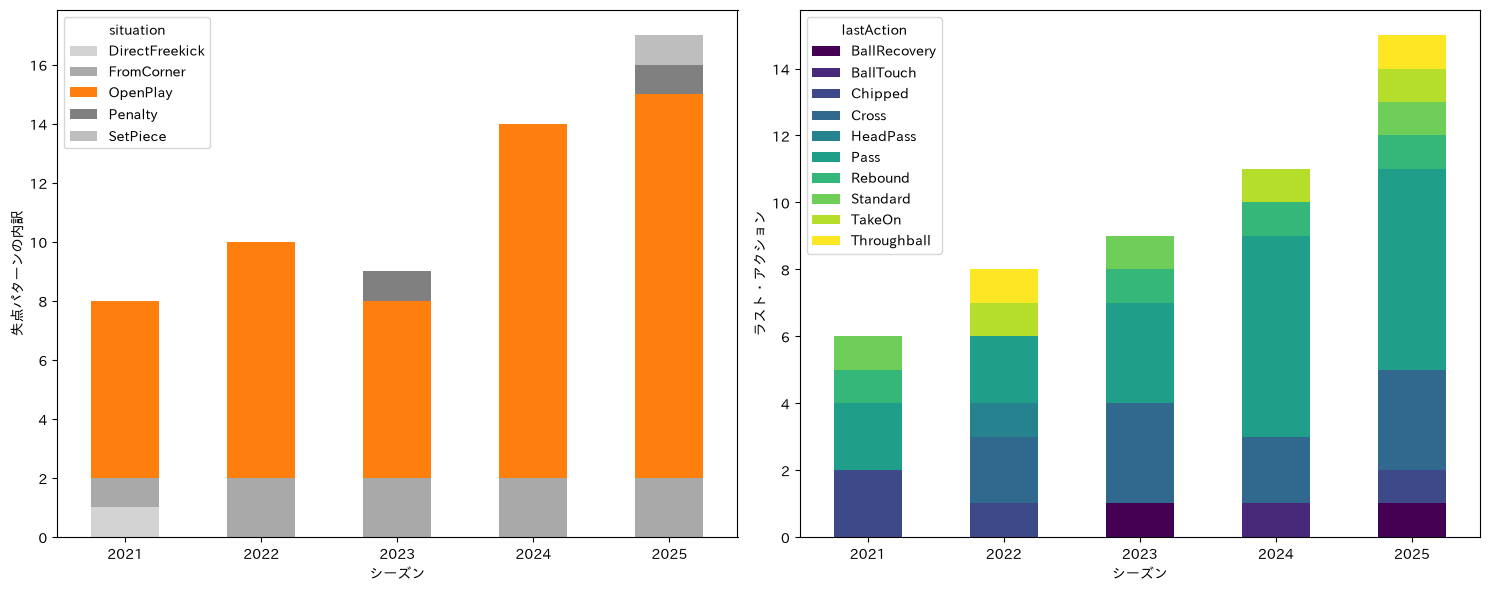

In [150]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

situation_colours = [
    '#d3d3d3',  # DirectFreekick (薄グレー)
    '#a9a9a9',  # FromCorner (中グレー)
    '#ff7f0e',  # OpenPlay (★鮮やかなオレンジで強調)
    '#808080',  # Penalty (濃グレー)
    '#bebebe'   # SetPiece (薄グレー)
]

cross_situation.plot(
    ax=axs[0],
    kind="bar",
    stacked=True,
    color=situation_colours,
    rot=0
)
axs[0].set_title("", fontsize=12)
axs[0].set_xlabel("シーズン")
axs[0].set_ylabel("失点パターンの内訳")

cross_last_action.plot(
    ax=axs[1],
    kind="bar",
    stacked=True,
    colormap="viridis",
    rot=0
)
axs[1].set_title("", fontsize=12)
axs[1].set_xlabel("シーズン")
axs[1].set_ylabel("ラスト・アクション")

plt.tight_layout()
plt.show()

# これより下はテスト用

In [159]:
cross_situation

situation,DirectFreekick,FromCorner,OpenPlay,Penalty,SetPiece
season,,,,,
2021,1,1,6,0,0
2022,0,2,8,0,0
2023,0,2,6,1,0
2024,0,2,12,0,0
2025,0,2,13,1,1


In [170]:
# OpenPlay以外の項目を一つにまとめる
situation_other_cols = cross_situation.columns.drop("OpenPlay")

In [171]:
cross_situation["OtherPlayTypes"] = cross_situation[situation_other_cols].sum(axis=1)

In [172]:
new_cross_situation = cross_situation[["OpenPlay", "OtherPlayTypes"]]

<Axes: xlabel='season'>

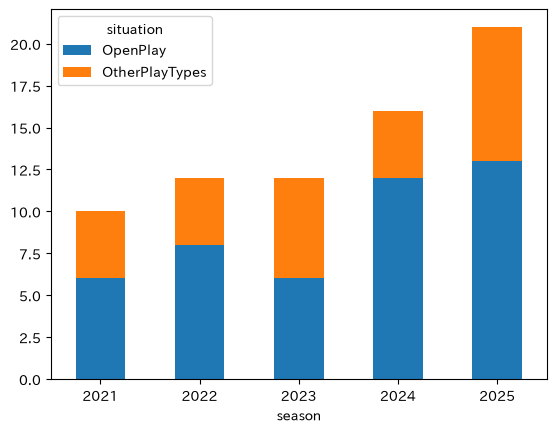

In [173]:
new_cross_situation.plot(
    kind="bar",
    stacked=True,
    rot=0
)

In [174]:
cross_last_action.head()

lastAction,BallRecovery,BallTouch,Chipped,Cross,HeadPass,Pass,Rebound,Standard,TakeOn,Throughball
season,,,,,,,,,,
2021,0,0,2,0,0,2,1,1,0,0
2022,0,0,1,2,1,2,0,0,1,1
2023,1,0,0,3,0,3,1,1,0,0
2024,0,1,0,2,0,6,1,0,1,0
2025,1,0,1,3,0,6,1,1,1,1


In [175]:
last_action_other_cols = cross_last_action.columns.drop(["Cross", "Pass"])

In [176]:
last_action_other_cols

Index(['BallRecovery', 'BallTouch', 'Chipped', 'HeadPass', 'Rebound',
       'Standard', 'TakeOn', 'Throughball'],
      dtype='str', name='lastAction')

In [177]:
cross_last_action["OtherActionTypes"] = cross_last_action[last_action_other_cols].sum(axis=1)

In [179]:
new_cross_last_action = cross_last_action[["Pass", "Cross", "OtherActionTypes"]]

<Axes: xlabel='season'>

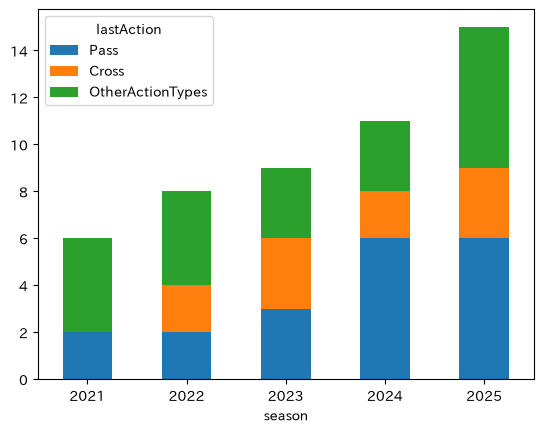

In [180]:
new_cross_last_action.plot(
    kind="bar",
    stacked=True,
    rot=0
)